<a href="https://colab.research.google.com/github/DenysovOleksii/Data-Driven-Retail-Analysis-SQL-Python-Tableau/blob/main/Ecommerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
from google.colab import auth
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
auth.authenticate_user()


In [137]:
#Connecting to DB and making dataset throught SQL query
project_id='data-analytics-mate'
query="""
SELECT
s.date,
o.ga_session_id,
sp.* EXCEPT(ga_session_id,medium,name),
sp.name as traffic_info,
acs.account_id,
acc.is_unsubscribed,
acc.is_verified,
p.* EXCEPT(item_id,name),
p.name as product_name
FROM `data-analytics-mate.DA.order` o
LEFT JOIN `data-analytics-mate.DA.product` p
ON o.item_id=p.item_id
LEFT JOIN `data-analytics-mate.DA.session` s
ON o.ga_session_id=s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.session_params` sp
ON o.ga_session_id=sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
ON o.ga_session_id=acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` acc
ON acs.account_id=acc.id
"""
df=pd.read_gbq(query,project_id=project_id)
df.info()

/tmp/ipykernel_3655/1367904612.py:26: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df=pd.read_gbq(query,project_id=project_id)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               33538 non-null  dbdate 
 1   ga_session_id      33538 non-null  Int64  
 2   device             33538 non-null  object 
 3   mobile_model_name  33538 non-null  object 
 4   operating_system   33538 non-null  object 
 5   language           22531 non-null  object 
 6   browser            33538 non-null  object 
 7   continent          33538 non-null  object 
 8   country            33538 non-null  object 
 9   channel            33538 non-null  object 
 10  traffic_info       33538 non-null  object 
 11  account_id         2781 non-null   Int64  
 12  is_unsubscribed    2781 non-null   Int64  
 13  is_verified        2781 non-null   Int64  
 14  category           33538 non-null  object 
 15  price              33538 non-null  float64
 16  short_description  335

## Опис датасету (Exploratory Data Analysis)

На основі вивантажених даних із Google BigQuery за період з **01.11.2020** по **27.01.2021**, було проведено первинний аналіз структури датасету.

### 1. Загальні характеристики
* **Загальна кількість рядків:** 33 538
* **Загальна кількість колонок:** 18
* **Кількість унікальних сесій:** 33 538 (кожен рядок відповідає унікальній сесії)


### 2. Типи даних
| Тип | Кількість | Колонки |
| :--- | :--- | :--- |
| **Числові (Numeric)** | 6 | `ga_session_id`, `account_id`, `is_unsubscribed`, `is_verified`, `price` |
| **Категоріальні (Object)** | 11 | `device`, `mobile_model_name`, `operating_system`, `language`, `browser`, `continent`, `country`, `channel`, `traffic_info`, `category`, `short_description`, `product_name` |
| **Дата (Datetime)** | 1 | `date` |

### 3. Аналіз пропущених значень (Missing Values)

У датасеті спостерігається значна кількість пропущених значень у певних колонках, що зумовлено специфікою збору даних.

| Колонка | Кількість пропусків | Причина виникнення |
| :--- | :--- | :--- |
| `account_id` | 30 757 | Більшість користувачів здійснюють покупки або перегляди без реєстрації (гостьові сесії). |
| `is_unsubscribed`| 30 757 | Дані доступні лише для профілів зареєстрованих користувачів. |
| `is_verified` | 30 757 | Статус підтвердження email існує лише для створених акаунтів. |
| `language` | 11 007 | Технічні обмеження браузерів або налаштування приватності користувачів, які не передають мовні параметри. |

**Висновок:** Датасет репрезентує переважно неавторизований трафік, що є типовим для інтернет-магазинів.

#Частина 1: Базові метрики, Географія та Користувачі

##Географічний лідерборд

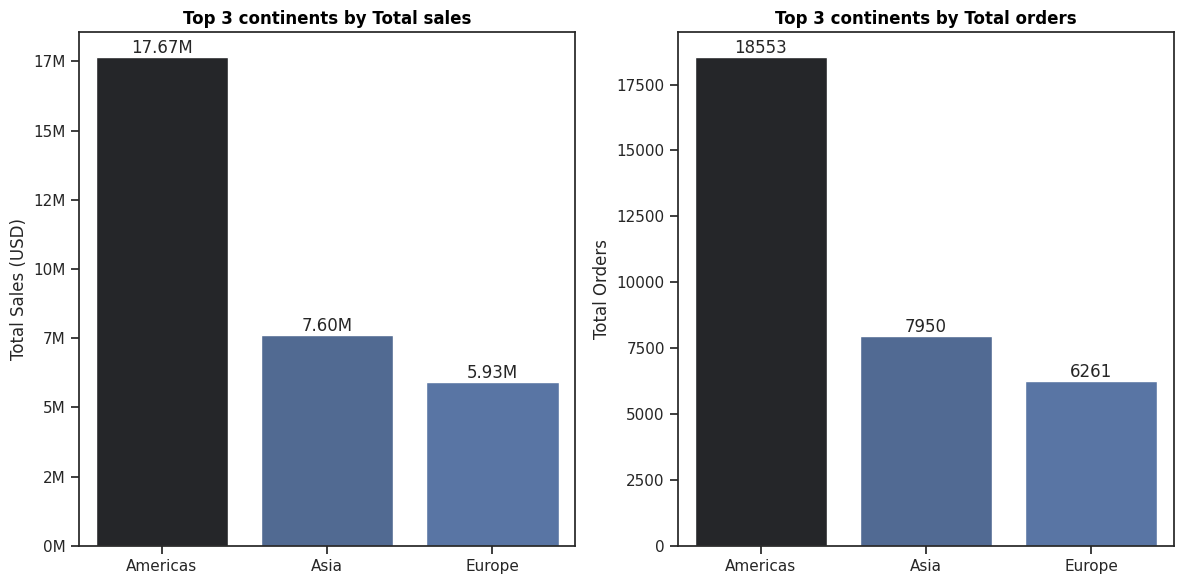

In [138]:
#Топ 3 континенти по продажам та кількістю замовлень

df_top3_cont=df.groupby("continent").agg(
    total_sales=("price", "sum"),
    order_count=("ga_session_id", "count")
).sort_values(by="total_sales", ascending=False).reset_index().head(3)
sns.set_theme(style="ticks")
fig,ax=plt.subplots(1,2,figsize=(12,6))
plot=sns.barplot(data=df_top3_cont,x="continent",y="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[0],legend=False)
ax[0].set_title("Top 3 continents by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[0].set_xlabel("")
ax[0].set_ylabel('Total Sales (USD)')
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x/1000000:.2f}M"))
plot2=sns.barplot(data=df_top3_cont,x="continent",y="order_count", hue="order_count",palette="dark:b_r",ax=ax[1],legend=False)
ax[1].set_title("Top 3 continents by Total orders",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].set_xlabel("")
ax[1].set_ylabel('Total Orders')
for bar in plot2.containers:
  plot2.bar_label(bar)
plt.tight_layout()
plt.show()


### 🌍 Географічний аналіз продажів: Континенти-лідери

Аналіз розподілу загального обсягу продажів (Загальні продажі) та кількості замовлень (Загальна кількість замовлень) у розрізі континентів виявив абсолютного лідера ринку — **макрорегіон Америка**.

| Континент | Обсяг продажів ($) | Кількість замовлень | Частка у продажах (%) |
| :--- | :---: | :---: | :---: |
| **Америка** | 17M | 18 553 | ~58.6% |
| **Азія** | 7M | 7 950 | ~24.1% |
| **Європа** | 5M | 6 261 | ~17.3% |

#### 🔑 Ключові інсайти:
* **Домінування американського ринку:** Регіон **Америка** генерує понад **58% усіх прибутків** компанії (17 млн) та забезпечує левову частку транзакцій (18 553 замовлення). Це ключовий та найбільш зрілий ринок для нашого інтернет-магазину.
* **Співвідношення Азії та Європи:** **Азія** впевнено посідає друге місце з обсягом у 7 млн продажів та 7 950 замовлень. **Європа** замикає топ-3 (5 млн продажів та 6 261 замовлення).
* **Стабільність середнього чека:** Розподіл замовлень майже ідеально пропорційний обсягам продажів на всіх трьох континентах. Це свідчить про те, що середній чек (AOV) у різних регіонах є приблизно однаковим, і масштабування виторгу відбувається саме за рахунок залучення більшої кількості сесій та транзакцій, а не через продаж дорожчих товарів у конкретних регіонах.

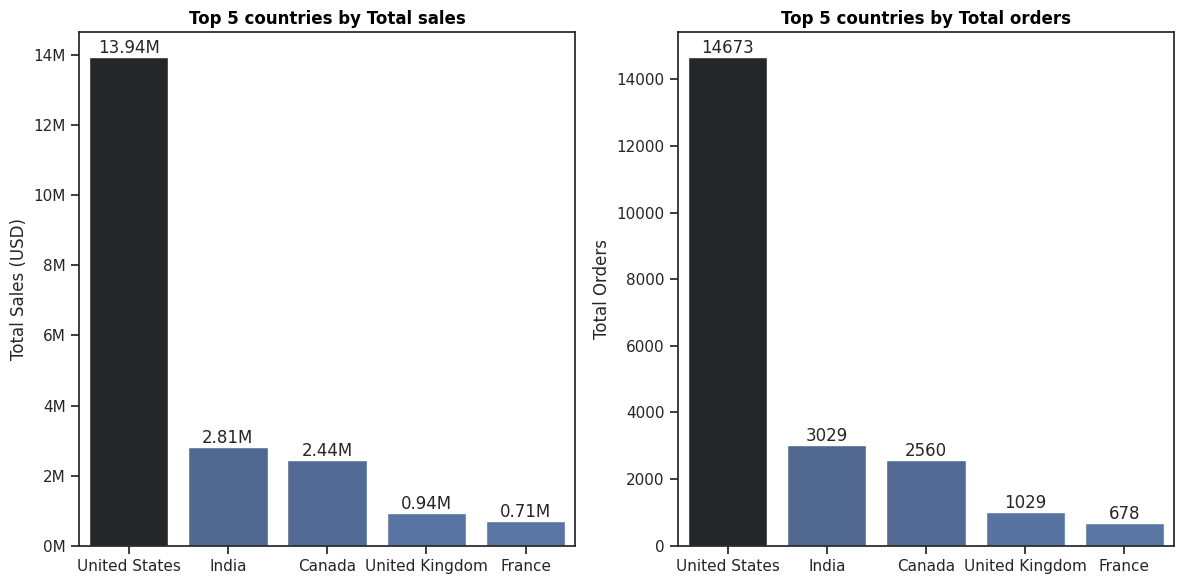

In [139]:
#Топ 5 країн по продажам та кількістю замовлень

df_top5_count=df.groupby("country").agg(
    total_sales=("price", "sum"),
    order_count=("ga_session_id", "count")
).sort_values(by="total_sales", ascending=False).reset_index().head(5)
sns.set_theme(style="ticks")
fig,ax=plt.subplots(1,2,figsize=(12,6))
plot=sns.barplot(data=df_top5_count,x="country",y="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[0],legend=False)
ax[0].set_title("Top 5 countries by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[0].set_xlabel("")
ax[0].set_ylabel('Total Sales (USD)')
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x/1000000:.2f}M"))
plot2=sns.barplot(data=df_top5_count,x="country",y="order_count", hue="order_count",palette="dark:b_r",ax=ax[1],legend=False)
ax[1].set_title("Top 5 countries by Total orders",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].set_xlabel("")
ax[1].set_ylabel('Total Orders')
for bar in plot2.containers:
  plot2.bar_label(bar)
plt.tight_layout()
plt.show()

### 🏳️ Географічний аналіз продажів: Країни-лідери

Глибокий аналіз у розрізі конкретних країн підтверджує критичну залежність бізнесу від одного ключового географічного ринку, а також формує чіткий пул регіонів для подальшого масштабування.

| Країна | Обсяг продажів, USD | Кількість замовлень | Середній чек (AOV, USD) |
|:---|:---|:---|:---|
| США | 13.94M | 14 673 | ~950 |
| Індія | 2.81M | 3 029 | ~927 |
| Канада | 2.44M | 2 560 | ~952 |
| Велика Британія | 0.94M | 1 029 | ~911 |
| Франція | 0.71M | 678 | ~1 047 |

#### 🔑 Ключові інсайти:

* **Абсолютне домінування США:** Сполучені Штати є головним джерелом прибутку, генеруючи **13.94 млн USD** продажів та забезпечуючи **14 673 замовлення**. Це становить близько **41.5%** від усього виторгу компанії.
* **Потенціал азійського вектору (Індія):** **Індія** впевнено посідає друге місце (**2.81 млн USD** та **3 029 замовлень**). Це ключовий ринок у регіоні Азія, який демонструє високу щільність транзакцій.
* **Ефективність європейського ринку (Франція):** Попри те, що **Франція** замикає Топ-5 за загальними обсягами (0.71 млн USD всього 678 замовлень), вона має найвищий середній чек серед лідерів — **понад 1000 USD** на замовлення.

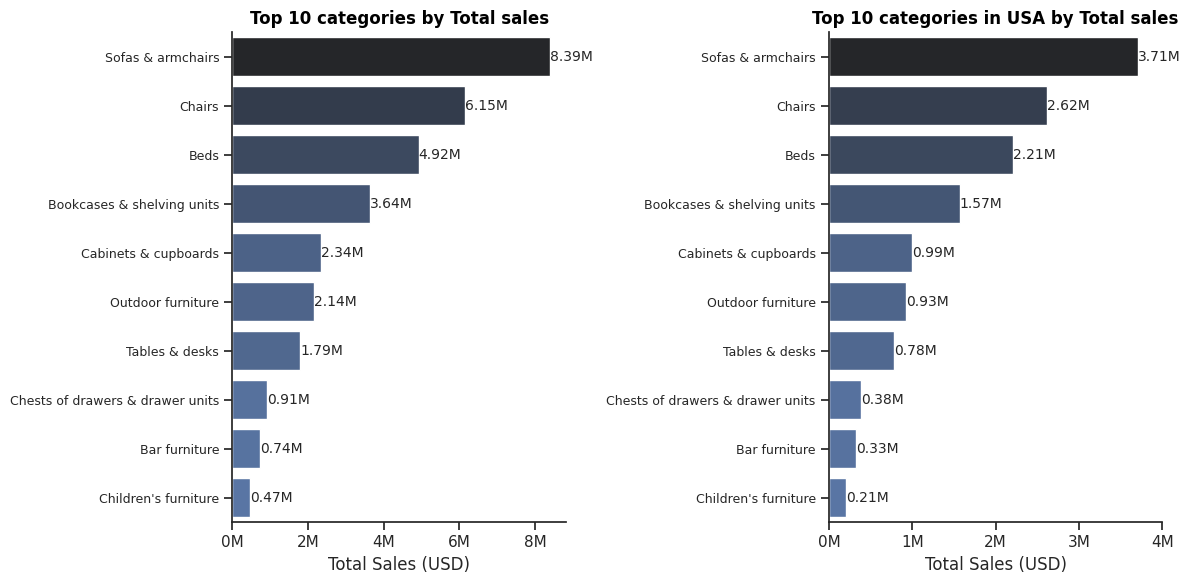

In [140]:
#Топ 10 категорій загально та у США
df_top10_category=df.groupby("category")["price"].sum().sort_values(ascending=False).reset_index(name="total_sales").head(10)
sns.set_theme(style="ticks")
fig,ax=plt.subplots(1,2,figsize=(12,6))
plot=sns.barplot(data=df_top10_category,y="category",x="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[0],legend=False)
ax[0].set_title("Top 10 categories by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[0].set_ylabel("")
ax[0].set_xlabel('Total Sales (USD)')
ax[0].tick_params(axis='y', labelsize=9)
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x/1000000:.2f}M"),fontsize=10)
df_top10usa_category=df[df["country"]=="United States"].groupby("category")["price"].sum().sort_values(ascending=False).reset_index(name="total_sales").head(10)
plot2=sns.barplot(data=df_top10usa_category,y="category",x="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[1],legend=False)
ax[1].set_title("Top 10 categories in USA by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[1].set_ylabel("")
ax[1].tick_params(axis='y', labelsize=9)
ax[1].set_xticks([0, 1000000, 2000000, 3000000, 4000000])
ax[1].set_xlabel('Total Sales (USD)')
for bar in plot2.containers:
  plot2.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x/1000000:.2f}M"),fontsize=10)
sns.despine()
plt.tight_layout()



### 📦 Категоріальний аналіз: Топ-10 категорій товарів

Аналіз структури продажів у розрізі категорій товарів дозволяє оцінити продуктові драйвери компанії, а також зіставити глобальні тренди споживчого попиту з уподобаннями клієнтів на ключовому ринку — в США.

| № | Категорія товару | Загальний виторг (USD) | Виторг в США (USD) | Частка ринку США (%) |
|:---|:---|:---|:---|:---|
| 1 | Sofas & armchairs | 8.39 M | 3.71 M | ~44.2% |
| 2 | Chairs | 6.15 M | 2.62 M | ~42.6% |
| 3 | Beds | 4.92 M | 2.21 M | ~44.9% |
| 4 | Bookcases & shelving units | 3.64 M | 1.57 M | ~43.1% |
| 5 | Cabinets & cupboards | 2.34 M | 0.99 M | ~42.3% |
| 6 | Outdoor furniture | 2.14 M | 0.93 M | ~43.5% |
| 7 | Tables & desks | 1.79 M | 0.78 M | ~43.6% |
| 8 | Chests of drawers & drawer units | 0.91 M | 0.38 M | ~41.8% |
| 9 | Bar furniture | 0.74 M | 0.33 M | ~44.6% |
| 10 | Children's furniture | 0.47 M | 0.21 M | ~44.7% |

#### 🔑 Ключові інсайти:

* **Повна ідентичність споживчої поведінки:** Структура попиту на топ-10 категорій товарів на глобальному рівні та всередині США є **абсолютно дзеркальною**. Позиції всіх товарних груп у рейтингу збігаються один в один — від абсолютного лідера `Sofas & armchairs` до замикаючої позиції `Children's furniture`. Це підтверджує універсальність продуктового портфеля компанії та єдині паттерни вибору меблів незалежно від регіону.
* **Ядро асортименту (Топ-3):** Головними драйверами доходу бізнесу виступають три категорії: **Sofas & armchairs** (8.39M загалом), **Chairs** (6.15M) та **Beds** (4.92M). Ця трійка формує основний фінансовий потік компанії.
* **Стабільна частка американського вектора:** На кожній продуктовій позиції чітко простежується, що ринок США стабільно акумулює **від 42% до 45%** загального світового виторгу конкретної категорії. Це ще раз підкреслює критичну залежність загального результату компанії від успіху американського підрозділу.

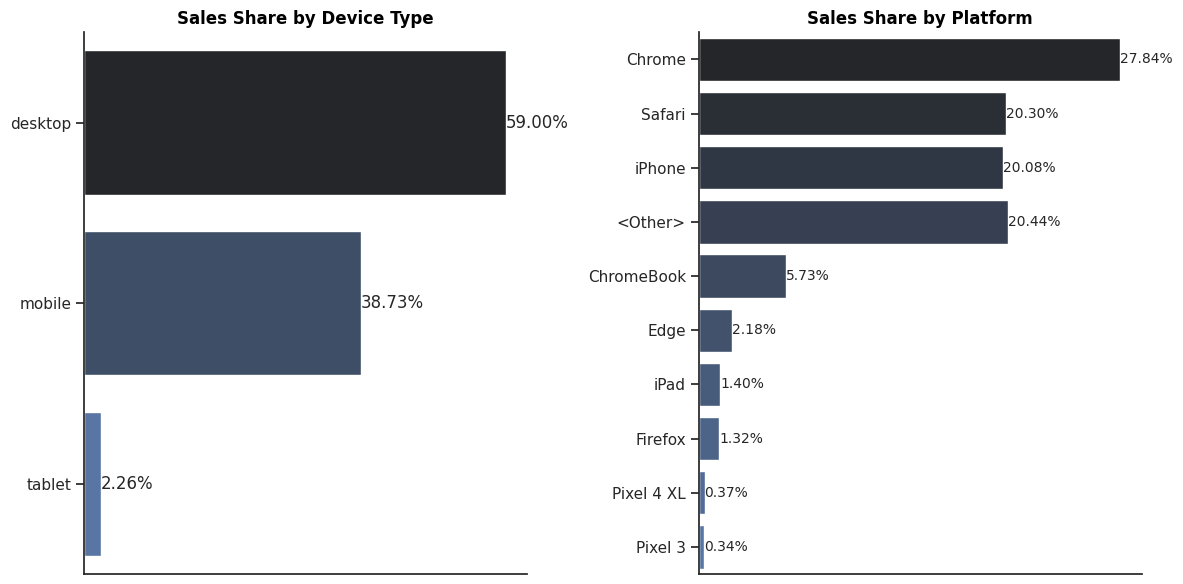

In [141]:
df_devices=df.groupby(["device","mobile_model_name"])["price"].sum().reset_index(name="total_sales").sort_values(by="total_sales",ascending=False)
df_devices["percent"]=df_devices['total_sales']/df['price'].sum()*100
fig,ax=plt.subplots(1,2,figsize=(12,6))
sns.set_theme(style="ticks")
plot=sns.barplot(data=df_devices,y="device",x="percent",ax=ax[0],errorbar=('ci', False),estimator="sum",palette="dark:b",hue="device")
ax[0].set_title("Sales Share by Device Type",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x}%"))
ax[0].set_ylabel("")
ax[0].set_xlabel("")
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x:.2f}%"))
plot2=sns.barplot(data=df_devices,y="mobile_model_name",x="percent",ax=ax[1],errorbar=('ci', False),estimator="sum",palette="dark:b",hue="mobile_model_name")
ax[1].set_title("Sales Share by Platform",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x}%"))
ax[1].set_ylabel("")
ax[1].set_xlabel("")
for bar in plot2.containers:
   plot2.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x:.2f}%"),fontsize=10)
ax[0].get_xaxis().set_visible(False)
ax[1].get_xaxis().set_visible(False)
sns.despine()
plt.tight_layout()


### 💻 Технічний аналіз: Продажі у розрізі девайсів та платформ

Цей етап аналізу дозволяє визначити технічні характеристики сесій, які приносять компанії найбільший дохід. Через специфіку збору даних (Google Analytics), загальний тип пристрою (`device`) деталізується через назву платформи або моделі (`model_name`), де для десктопів фіксується веб-браузер, а для мобільних — конкретний девайс.

#### 📊 Глобальний розподіл та Топ-10 платформ за часткою продажів

| № | Тип пристрою (device) | Частка (%) | | № | Платформа / Модель (model_name) | Частка (%) |
|:---|:---|:---|:---|:---|:---|:---|
| 1 | **desktop** | 59.00% | | 1 | Chrome | 27.84% |
| 2 | **mobile** | 38.73% | | 2 | <Other> | 20.44% |
| 3 | **tablet** | 2.26% | | 3 | Safari | 20.30% |
|   |            |        | | 4 | iPhone | 20.08% |
|   |            |        | | 5 | ChromeBook | 5.73% |
|   |            |        | | 6 | Edge | 2.18% |
|   |            |        | | 7 | iPad | 1.40% |
|   |            |        | | 8 | Firefox | 1.32% |
|   |            |        | | 9 | Pixel 4 XL | 0.37% |
|   |            |        | | 10 | Pixel 3 | 0.34% |

#### 🔑 Ключові інсайти:

* **Домінування десктопного сегменту:** Понад **59% всього виторгу** компанії генерують користувачі настільних комп'ютерів (`desktop`). Основними інструментами є браузери `Chrome` (27.84%) та `Safari` (20.30%). Це підтверджує, що класична web-версія сайту є головним та найбільш конверсійним каналом монетизації.
* **Смартфони як потужний другий канал:** Мобільні пристрої (`mobile`) міцно утримують частку в **38.73%**. При цьому всередині мобільного сегменту спостерігається чіткий поділ: користувачі **iPhone** забезпечують аж **20.08%** від загальних світових продажів компанії, повністю домінуючи над смартфонами на Android (лінійки Pixel 3/4 сукупно приносять менше 1%).

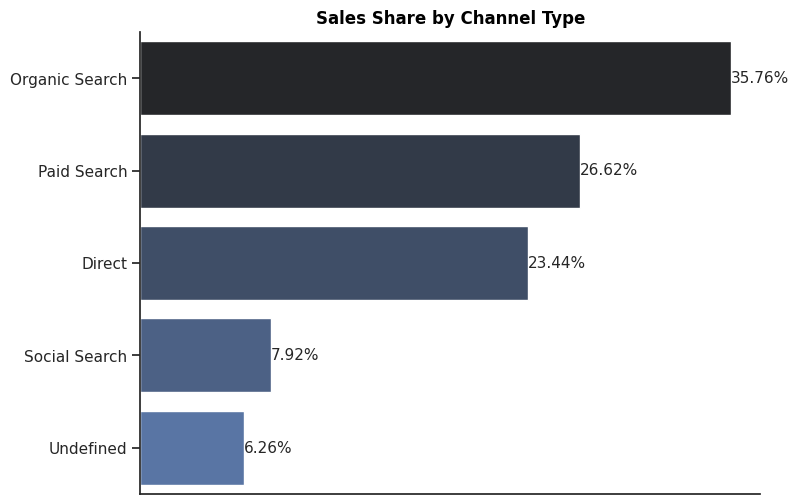

In [142]:
df_channels=df.groupby("channel")["price"].sum().reset_index(name="total_sales").sort_values(by="total_sales",ascending=False)
df_channels["percent"]=df_channels['total_sales']/df['price'].sum()*100
plt.figure(figsize=(8, 6))
sns.set_theme(style="ticks")
plot=sns.barplot(data=df_channels,y="channel",x="percent",errorbar=('ci', False),estimator="sum",palette="dark:b",hue="channel")
plot.set_title("Sales Share by Channel Type",fontsize=12,fontweight="bold",color="Black",ha="center")
plot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x}%"))
plot.set_ylabel("")
plot.set_xlabel("")
plot.get_xaxis().set_visible(False)
sns.despine()
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x:.2f}%"),fontsize=11)

### 🌐 Аналіз каналів трафіку: Розподіл продажів

Цей етап аналізу дозволяє оцінити ефективність маркетингових каналів залучення користувачів та зрозуміти, які джерела генерують основний обсяг фінансового результату компанії.

#### 📊 Структура продажів за джерелами трафіку (Channel Type)

| № | Канал трафіку (Channel Type) | Частка від загальних продажів (%) | Роль у маркетинговій стратегії |
|:---|:---|:---|:---|
| 1 | **Organic Search** | 35.76% | Основний драйвер умовно-безкоштовного трафіку (SEO) |
| 2 | **Paid Search** | 26.62% | Головний платний канал залучення (Контекстна реклама) |
| 3 | **Direct** | 23.44% | Прямі заходи (Ядро лояльної аудиторії / Сила бренду) |
| 4 | **Social Search** | 7.92% | Допоміжний канал залучення через соціальні мережі |
| 5 | **Undefined** | 6.26% | Технічні сесії без визначеного UTM-джерела |

#### 🔑 Ключові інсайти:

* **Домінування пошукового вектору (Понад 62%):** Сумарно органічний та платний пошук (`Organic Search` + `Paid Search`) забезпечують понад **62% всього виторгу** компанії. Це свідчить про те, що продукт має сформований попит, і користувачі активно шукають його через пошукові системи.
* **Здоровий баланс між платоспроможністю та витратами:** Найбільшу частку доходу приносить безкоштовний органічний пошук (**35.76%**), що вказує на сильну SEO-оптимізацію та високу позицію сайту в пошуковиках. При цьому платна реклама (`Paid Search` — **26.62%**) виступає потужним паливом, що підтримує високу швидкість масштабування продажів.
* **Високий рівень лояльності бренду:** Прямі заходи на сайт (`Direct`) генерують майже чверть доходу (**23.44%**). Це чудовий показник для e-commerce, який підтверджує, що значна частина клієнтів повертається до магазину напряму (через закладки або пам'ять), довіряє бренду та має високий рівень утримання (Retention).

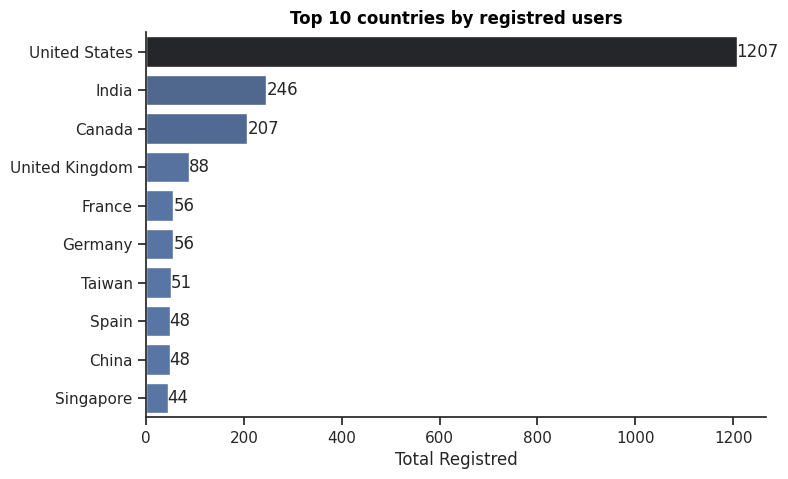

In [143]:
df_top10_registred=df[df['account_id'].notna()]
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
plot=sns.barplot(data=df_top10_registred['country'].value_counts().head(10).reset_index(),y="country",x="count",palette="dark:b_r",hue="count",legend=False)
plot.set_title("Top 10 countries by registred users",fontsize=12,fontweight="bold",color="Black",ha="center")
plot.set_ylabel("")
plot.set_xlabel("Total Registred")
sns.despine()
for bar in plot.containers:
  plot.bar_label(bar)


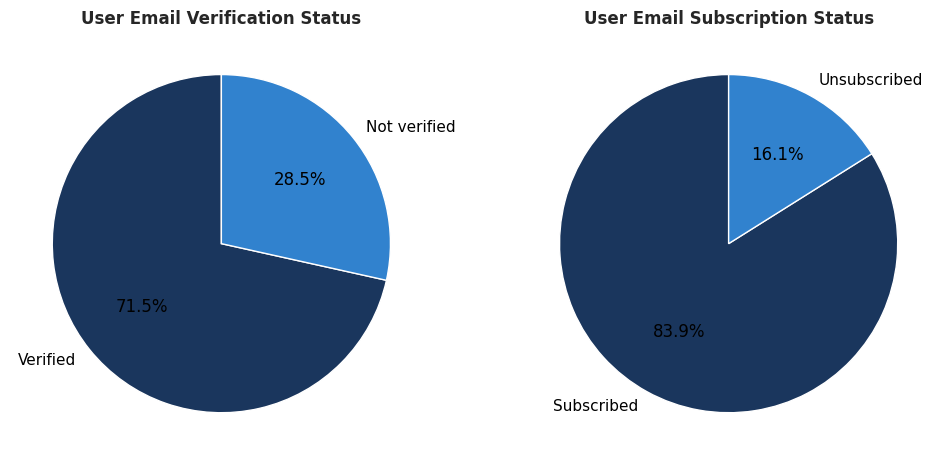

In [144]:
df_accounts=df[df['account_id'].notna()].reset_index()
fig,ax=plt.subplots(1,2,figsize=(12,6))
df_accounts["is_verified"].value_counts(normalize=True).plot(kind="pie",labels=["Verified", "Not verified"],autopct="%1.1f%%",startangle=90,colors=["#1a365d", "#3182ce"], textprops={'color': "black"},ylabel="", ax=ax[0]
)
ax[0].set_title("User Email Verification Status", fontsize=12, fontweight="bold")
df_accounts["is_unsubscribed"].value_counts(normalize=True).plot(kind="pie",labels=["Subscribed", "Unsubscribed"],autopct="%1.1f%%",startangle=90,colors=["#1a365d", "#3182ce"], textprops={'color': "black"},ylabel="", ax=ax[1]
)
ax[1].set_title("User Email Subscription Status", fontsize=12, fontweight="bold")
plt.show()

👥 Аналіз поведінки користувачів: Географія, верифікація та підписки

Цей етап аналізу дозволяє оцінити географічний розподіл аудиторії, якість контактної бази зареєстрованих користувачів, рівень їхньої взаємодії з платформою та готовність до комунікації через email-маркетинг.

## 📊 Метрики профілів користувачів

| Метрика | Статус профілю / Регіон | Частка від загальної кількості акаунтів / К-сть |
|:---|:---|:---|
| **Географічний лідер** | United States (США) | 43.4% (1207 акаунтів) |
| **Top-3 ринки** | US, India (246), Canada (207) | 59.7% (Разом 1660 акаунтів) |
| **Email Verification** | Verified (Підтверджений) | 71.5% |
| | Not verified (Не підтверджений) | 28.5% |
| **Subscription Status**| Subscribed (Підписаний на розсилку) | 83.9% |
| | Unsubscribed (Відписався) | 16.1% |

## 🔑 Ключові інсайти

* **Концентрація аудиторії в США та англомовних регіонах:** Основна частина користувачів зареєстрована в США — 1207 акаунтів (43.4% від загальної бази). Разом із Канадою та Індією три лідуючі країни формують 59.7% усіх реєстрацій. Маркетингові та email-кампанії мають орієнтуватися на англомовну аудиторію та специфіку американського ринку.
* **Якість реєстрацій:** Показник у 71.5% верифікованих адрес підтверджує коректну роботу процесу реєстрації та доставку тригерних листів. При цьому 28.5% користувачів не підтвердили пошту. Для зниження цього показника доцільно протестувати додаткові стимули (наприклад, промокоди для нових користувачів із фокусом на США).
* **Конверсія в підписку:** 83.9% користувачів залишаються підписаними на маркетингові розсилки компанії. Рівень відписок (Churn Rate) становить 16.1%, що є стандартним показником для роздрібної торгівлі. Наявна база дозволяє ефективно налаштовувати повторні продажі через email-канал.

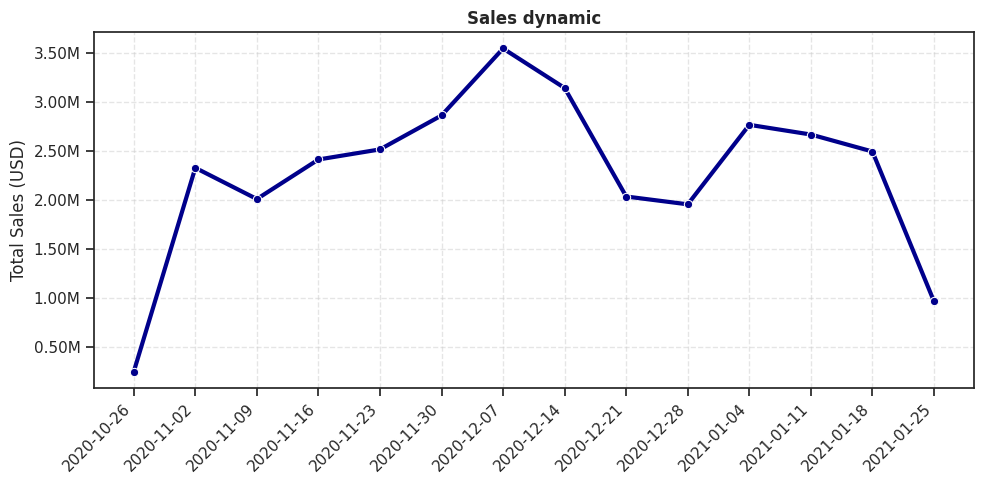

In [205]:
df["date"] = pd.to_datetime(df["date"])
df['week']=df['date'].dt.to_period('W').dt.start_time
df_weekly = df.groupby("week")["price"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_weekly, x='week', y='price', marker='o', color="darkblue", lw=3)
plt.xticks(ticks=df_weekly['week'], labels=df_weekly['week'].dt.strftime('%Y-%m-%d'), rotation=45, ha='right')
plt.title('Sales dynamic', fontsize=12, fontweight='bold')
plt.xlabel("")
plt.ylabel('Total Sales (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000000:.2f}M"))
plt.tight_layout()
plt.show()

# 📈 Аналіз загальної динаміки продажів та сезонності

Аналіз тижневих показників виручки дозволяє оцінити стабільність надходження грошових потоків, виявити періоди пікової активності та визначити наявність сезонних факторів, що впливають на обсяг продажів.

## 📊 Динаміка загальних продажів по тижнях

Графік відображає зміну обсягу виручки (Total Sales у млн USD) з кроком в один тиждень за період з листопада 2020 року по лютий 2021 року.

## 🔑 Ключові інсайти:

* **Період максимального фінансового зростання:** Найвищий рівень продажів зафіксовано в першій половині грудня. Пік активності припадає на тиждень **2020-12-13**, коли обсяг виручки досяг максимальної позначки — понад **3.50 млн USD**. Зростання показників починається з середини листопада (від 2.00 млн USD) і триває до середини грудня, що безпосередньо пов'язано з макроекономічним фактором передноворічних закупівель.
* **Тренди та сезонні коливання:** В аналізованому періоді чітко простежується сезонність:
  * **Передноворічний сплеск:** Період з 22 листопада по 20 грудня характеризується стабільно високим попитом із середнім показником вище 2.80 млн USD на тиждень.
  * **Постсвятковий спад:** Одразу після піку відбувається стрімке падіння продажів майже вдвічі — до **2.00 млн USD** на тижні 2020-12-27 та 2021-01-03. Це свідчить про повне затухання купівельної активності в кінці грудня та на початку січня.
* **Повторна хвиля активності (Січневий відскок):** Після святкового спаду спостерігається короткострокове відновлення ринку з піком на тижні **2021-01-10** на рівні **2.75 млн USD**. Цей сплеск може бути зумовлений початком зимових розпродажів або виконанням відкладених замовлень.
* **Критичне падіння в кінці періоду:** Починаючи з середини січня, динаміка демонструє стійкий спад. На тижні **2021-01-31** зафіксовано падіння виручки до мінімального рівня — нижче **1.00 млн USD**. Це вказує на перехід бізнесу в низький сезонний період після завершення зимових акцій.

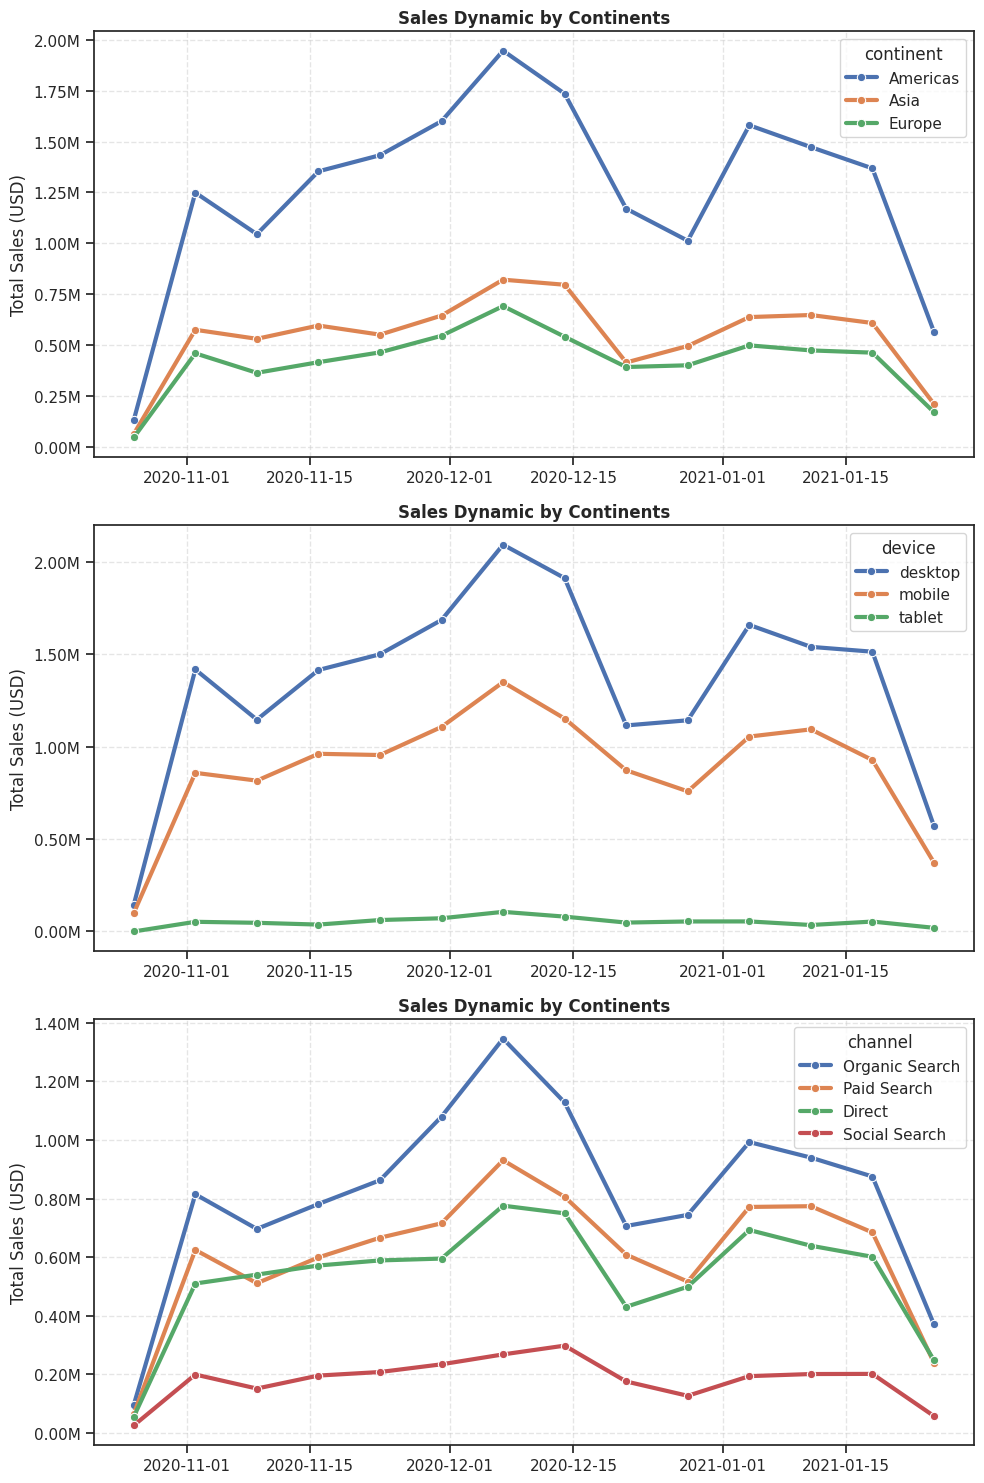

In [215]:
df_conti=df.pivot_table(index="week",columns="continent",values="price",aggfunc="sum")[["Americas","Asia","Europe"]]
df_devi=df.pivot_table(index="week",columns="device",values="price",aggfunc="sum")
df_chan=df.pivot_table(index="week",columns="channel",values="price",aggfunc="sum")[['Organic Search', 'Paid Search', 'Direct', 'Social Search']]
fig,ax=plt.subplots(3,1,figsize=(10,15))
sns.lineplot(data=df_conti,marker='o', color="darkblue", lw=3,ax=ax[0],dashes=False)
y_formatter = plt.FuncFormatter(lambda x, _: f"{x/1000000:.2f}M")
ax[0].set_title('Sales Dynamic by Continents', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Total Sales (USD)')
ax[0].set_xlabel('')
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].yaxis.set_major_formatter(y_formatter)
sns.lineplot(data=df_devi,marker='o', color="darkblue", lw=3,ax=ax[1],dashes=False)
ax[1].set_title('Sales Dynamic by Continents', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Total Sales (USD)')
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].yaxis.set_major_formatter(y_formatter)
ax[1].set_xlabel('')
sns.lineplot(data=df_chan,marker='o', color="darkblue", lw=3,ax=ax[2],dashes=False)
ax[2].set_title('Sales Dynamic by Continents', fontsize=12, fontweight='bold')
ax[2].set_ylabel('Total Sales (USD)')
ax[2].grid(True, linestyle='--', alpha=0.5)
ax[2].yaxis.set_major_formatter(y_formatter)
ax[2].set_xlabel('')
plt.tight_layout()
plt.show()

# 📈 Мультифакторний аналіз динаміки продажів (Континенти, Пристрої, Канали)

Комплексний аналіз тижневої виручки у розрізі географії, технічних платформ та каналів залучення користувачів дозволяє локалізувати джерела фінансових потоків та визначити драйвери передноворічного сплеску й постсвяткового спаду.

---

## 📊 1. Динаміка продажів за континентами

Перший графік відображає розподіл тижневої виручки між ключовими світовими макрорегіонами: Америка, Азія та Європа.

### 🔑 Ключові інсайти:
* **Абсолютне лідерство американського ринку:** Регіон Америка є головним генератором доходу компанії на усьому аналізованому проміжку. На піку передноворічних продажів (тиждень **2020-12-06**) тижнева виручка цього ринку досягла історичного максимуму — **1.95 млн USD**, що майже вдвічі перевищує сумарний дохід Азії та Європи разом узятих за той самий період.
* **Синхронність сезонних коливань:** Попри суттєву різницю в масштабах, усі три макрорегіони демонструють абсолютно ідентичні тренди: одночасне зростання з листопада до початку грудня, різке падіння наприкінці року (мінімум **2021-01-03**) та короткостроковий січневий відскок. Це свідчить про єдину глобальну бізнес-модель, що однаково залежить від загальносвітового календаря свят та розпродажів.
* **Аутсайдер кластера — Європа:** Ринок Європи стабільно замикає трійку лідерів, не піднімаючись вище позначки **0.70 млн USD** навіть у період максимального попиту, що вказує на слабшу присутність бренду або вищу конкуренцію в європейському сегменті.

---

## 💻 2. Динаміка продажів за типами пристроїв

Другий графік деталізує виручку залежно від платформ, з яких користувачі здійснювали покупки: комп'ютери, мобільні телефони та планшети.

### 🔑 Ключові інсайти:
* **Домінування десктопної версії:** Основним каналом конвертації трафіку в реальні гроші залишаються комп'ютери. У піковий тиждень грудня продажі з десктопу перевалили за позначку **2.10 млн USD**. Це класичний показник для електронної комерції у сфері меблів або дорогих товарів, де користувачі схильні приймати фінальні рішення про покупку та вносити великі платежі з великих екранів.
* **Мобільний трафік як стабільне вторинне джерело:** Продажі через мобільні пристрої повторюють загальну динаміку ринку, досягаючи піку в **1.35 млн USD**. Стабільний розрив між комп'ютерами та смартфонами вказує на те, що мобільна версія виступає або допоміжним інструментом, або каналом швидких покупок, але не основним драйвером надвисоких чеків.
* **Повна відсутність комерційної цінності планшетів:** Частка планшетів наближена до нуля протягом усього звітного періоду (стабільні показники в межах **0.05M – 0.10M USD**). Цей канал не реагує ні на сезонне зростання, ні на розпродажі, що робить його неефективним для подальшого маркетингового інвестування.

---

## 🔗 3. Динаміка продажів за каналами залучення

Третій графік візуалізує ефективність маркетингових каналів: органічний пошук, платна реклама, прямі заходи та соціальні мережі.

### 🔑 Ключові інсайти:
* **Фундаментальна роль органічного пошуку:** Безкоштовний пошуковий трафік приносить найбільший обсяг виручки, досягаючи пікових **1.35 млн USD**. Це свідчить про високий рівень пошукової оптимізації платформи, сильну впізнаваність бренду та сформовану базу лояльних клієнтів, які шукають товари цілеспрямовано.
* **Ефективність платного залучення та прямого трафіку:** Канали платної реклами та прямих заходів на сайт йдуть практично паралельно, забезпечуючи в пікові періоди **0.95 млн USD** та **0.78 млн USD** відповідно. Синхронний зліт платного трафіку в листопаді та грудні підтверджує агресивне й виправдане масштабування рекламних бюджетів під час високого сезону.
* **Низька конверсія соціальних мереж:** Канал соціальних мереж демонструє найнижчу ефективність, утримуючи продажі на рівні **0.20M – 0.30M USD** навіть на піку загального споживання. Соціальні платформи у цій бізнес-моделі працюють скоріше як медійний інструмент для знайомства з продуктом, аніж як майданчик для прямих та швидких продажів.

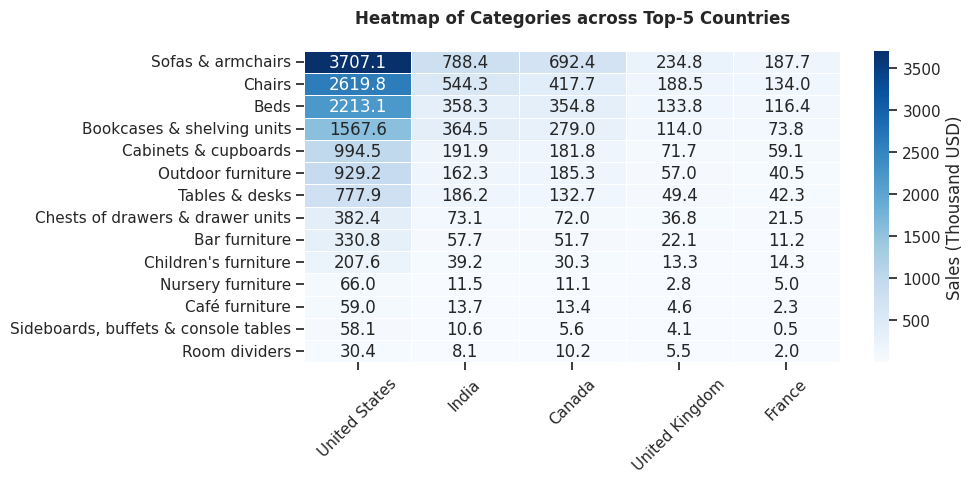

In [146]:
sort_countries=df.pivot_table(columns="country",index="category",aggfunc="sum",values="price",fill_value=0).sum(axis=1).sort_values(ascending=False).index
sort_categories=df.pivot_table(columns="country",index="category",aggfunc="sum",values="price",fill_value=0).sum().sort_values(ascending=False).head(5).index
df_top=df.pivot_table(columns="country",index="category",aggfunc="sum",values="price",fill_value=0).loc[sort_countries,sort_categories]
plt.figure(figsize=(10, 5))

df_top_thousands = df_top / 1000

sns.heatmap(
    data=df_top_thousands,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={'label': 'Sales (Thousand USD)'}
)

plt.title("Heatmap of Categories across Top-5 Countries", fontsize=12, fontweight="bold", pad=20)
plt.xticks(rotation=45)
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()


### 📊 Візуальний аналіз розподілу продажів (Heatmap)

Ця теплова карта демонструє розподіл обсягів продажів (у тисячах USD) між географічними ринками та всіма категоріями товарів. Візуалізація дозволяє визначити зони максимальної концентрації доходу та порівняти структуру попиту між країнами.

#### 🔑 Ключові інсайти:

* **Домінування ринку Сполучених Штатів Америки:** Найвищі показники продажів зафіксовані у стовпчику Сполучені Штати Америки (США). Продажі в категорії диванів та крісел (`Sofas & armchairs`) у США становлять 3,707.1 тис. USD, що є максимальним показником у грошовому еквіваленті для всього бізнесу. Обсяг продажів другорядних категорій у США перевищує дохід від топових категорій в інших країнах.
* **Однорідність структури попиту:** Градація кольору знижується зверху вниз однаково для всіх аналізованих країн. Це свідчить про ідентичність глобальних трендів споживання: у всіх регіонах пріоритетними є категорії диванів, стільців (`Chairs`) та ліжок (`Beds`), тоді як мінімальний дохід генерують категорії офісних, дитячих та барних меблів.
* **Порівняльний аналіз інших ринків:** Показники продажів в Індії та Канаді перебувають на сумірному рівні. Наприклад, категорія ліжок (`Beds`) згенерувала 358.3 тис. USD в Індії та 354.8 тис. USD у Канаді. Європейський кластер, представлений Великою Британією та Францією, демонструє найнижчі обсяги продажів серед топ-5 країн у всіх товарних категоріях.

In [147]:
df.pivot_table(index="continent",columns="device",aggfunc="mean",values="price",fill_value=0)

device,desktop,mobile,tablet
continent,,,
(not set),1032.868000,1117.700000,70.000000
Africa,1030.017021,907.484722,987.142857
Americas,962.172997,936.255772,966.604239
Asia,940.149013,971.464357,1110.690751
Europe,955.426005,935.086084,978.018939
Oceania,1039.483966,942.733051,847.777778


### 🌍  Аналіз середнього чека (Континенти проти типів пристроїв)

Ця зведена таблиця відображає вартість середнього замовлення (AOV у USD) залежно від географічного регіону клієнта та типу пристрою, з якого здійснюється покупка.

| Континент (continent) | Desktop (USD) | Mobile (USD) | Tablet (USD) |
|:---|:---:|:---:|:---:|
| **Africa** | 1030.02 | 907.48 | 987.14 |
| **Americas** | 962.17 | 936.26 | 966.60 |
| **Asia** | 940.15 | 971.46 | 1110.69 |
| **Europe** | 955.43 | 935.09 | 978.02 |
| **Oceania** | 1039.48 | 942.73 | 847.78 |

#### 🔑 Ключові інсайти:

* **Глобальна стабільність та однорідність ринків:** Результати розрахунків показують, що вартість середнього чека практично не залежить від того, з якого пристрою користувач купує меблі. На трьох основних світових ринках (**Americas, Europe, Asia**) показники середнього чека на десктопах та смартфонах майже ідентичні та стабільно утримуються у вузькому діапазоні від **935.09 до 971.46 USD**. Поведінка покупців у всьому світі є універсальною.
* **Специфіка мобільного трафіку:** Високий рівень середнього чека на смартфонах в Америці (**936.26 USD**) та Європі (**935.09 USD**) доводить, що користувачі мобільних пристроїв готові купувати дорогі та габаритні товари нарівні з користувачами ПК. Мобільна версія платформи є повністю ефективною та не обмежує покупців у бюджеті.
* **Регіональні відхилення та аномалії:** * Найвищий середній чек зафіксовано в Азії на планшетах (`Asia / tablet`) — **1,110.69 USD**, що вказує на поодинокі замовлення преміум-сегмента.
  * Ринки `Africa` та `Oceania` показують зміщення чека в бік десктопів (понад 1030 USD), що може бути зумовлено специфікою оформлення великих замовлень або вищою вартістю логістики у ці регіони.


#Статистичний аналіз взаємозв’язків

(NormaltestResult(statistic=np.float64(9.879636561665645), pvalue=np.float64(0.007155898618108501)),
 <Axes: xlabel='total_sales', ylabel='Count'>)

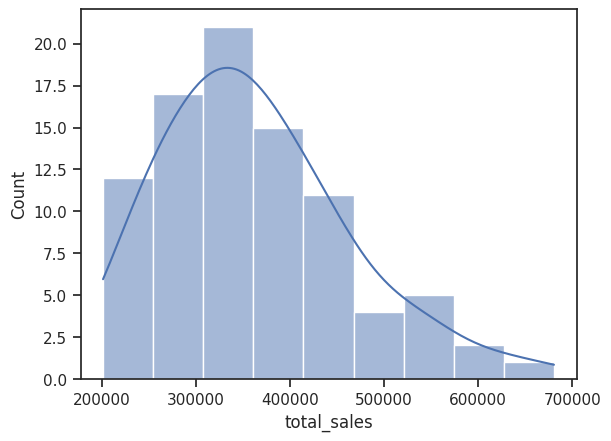

In [148]:
df_corr=df.groupby("date").agg(total_sales=("price","sum"),total_orders=("ga_session_id","count")).reset_index()
stats.normaltest(df_corr["total_sales"]),sns.histplot(data=df_corr["total_sales"],kde=True)


(NormaltestResult(statistic=np.float64(7.511406194248881), pvalue=np.float64(0.023384003602276295)),
 <Axes: xlabel='total_orders', ylabel='Count'>)

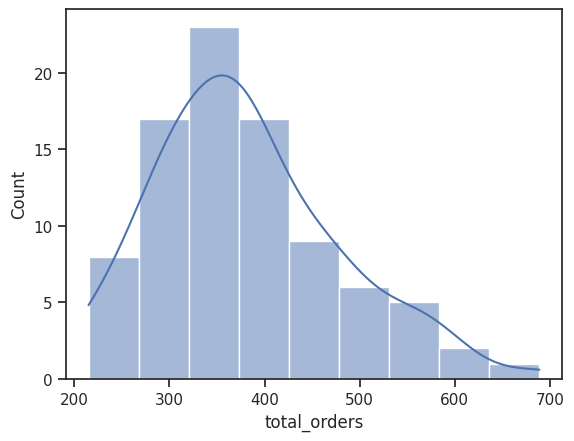

In [149]:
stats.normaltest(df_corr["total_orders"]),sns.histplot(data=df_corr["total_orders"],kde=True)

(SignificanceResult(statistic=np.float64(0.950959845605782), pvalue=np.float64(1.346332900826623e-45)),
 <Axes: xlabel='total_orders', ylabel='total_sales'>)

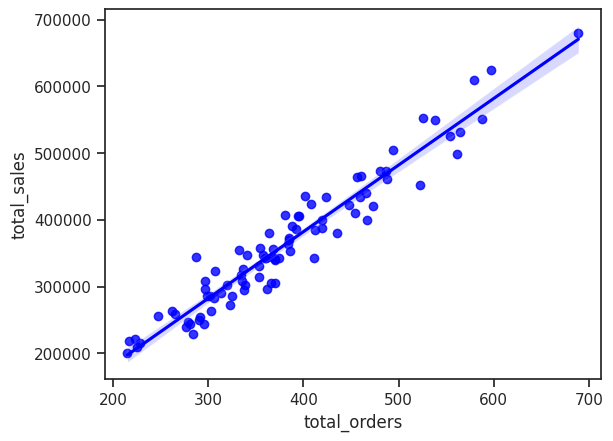

In [150]:
stats.spearmanr(df_corr['total_sales'], df_corr['total_orders']),sns.regplot(x='total_orders', y='total_sales', data=df_corr, color='blue')


# 📉 Статистичний аналіз взаємозв’язків

### 1. Взаємозв'язок між кількістю замовлень та загальними продажами за датами

Для аналізу зв'язку між щоденною активністю покупців та фінансовими результатами було проведено попереднє тестування розподілу метрик на нормальність за допомогою критерію Д'Агостіно (`stats.normaltest`).

* **Результат тесту для щоденного виторгу (`total_sales`):** $p$-value = 0.00715
* **Результат тесту для кількості замовлень (`total_orders`):** $p$-value = 0.02338

**Обґрунтування вибору метрики:** Оскільки для обох показників значення $p$-value < 0.05, гіпотезу про їхній нормальний розподіл було офіційно відхилено. На гістограмах чітко помітна правостороння асиметрія (наявність довгих хвостів у бік високих значень), що відображає специфіку e-commerce: дні проведення масштабних розпродажів або маркетингових акцій створюють сильні викиди.

У таких умовах лінійний коефіцієнт Пірсона працює некоректно. Для оцінки взаємозв'язку було обрано **непараметричний коефіцієнт рангової кореляції Спірмена (Spearman's rho)**, який стійкий до відхилень від нормальності та працює з рангами даних.

#### 📊 Результати розрахунку кореляції Спірмена:
* **Коефіцієнт кореляції Спірмена ($r_s$):** 0.9510
* **Статистична значущість ($p$-value):** $1.35 \times 10^{-45}$

#### 🔑 Ключові інсайти:
* **Майже ідеальний зв'язок:** Значення коефіцієнта $r_s = 0.9510$ свідчить про надзвичайно сильну, пряму монотонну залежність між кількістю оформлених кошиків та фінальним щоденним виторгом. Динаміка замовлень практично лінійно визначає фінансовий успіх платформи: кожен новий чек стабільно масштабує загальну касу без просідання в середній вартості товарів.
* **Абсолютна статистична значущість:** Отримане значення $p$-value ($1.35 \times 10^{-45}$) прагне до нуля і є критично меншим за стандартний рівень альфа ($\alpha = 0.05$). Це залізобетонно доводить, що виявлена залежність є стійкою бізнес-закономірністю, а ризик отримати такий результат випадково повністю дорівнює нулю.

In [151]:
df_cont_top3=df.groupby(['date', 'continent'])['price'].sum().unstack(fill_value=0)[['Americas', 'Asia', 'Europe']]
matrix_cont = df_cont_top3.corr(method='spearman')
print("\nПеревірка статистичної значущості (p-value):")
print(f"Americas vs Asia: p-value = {stats.spearmanr(df_cont_top3['Americas'], df_cont_top3['Asia']).pvalue:.5f}")
print(f"Americas vs Europe: p-value = {stats.spearmanr(df_cont_top3['Americas'], df_cont_top3['Europe']).pvalue:.5f}")
print(f"Asia vs Europe: p-value = {stats.spearmanr(df_cont_top3['Asia'], df_cont_top3['Europe']).pvalue:.5f}")
matrix_cont



Перевірка статистичної значущості (p-value):
Americas vs Asia: p-value = 0.00000
Americas vs Europe: p-value = 0.00000
Asia vs Europe: p-value = 0.00000


continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.668539,0.625885
Asia,0.668539,1.000000,0.608221
Europe,0.625885,0.608221,1.000000


### 🌍 2. Кореляція продажів між різними континентами (Топ-3)

Для аналізу синхронності глобальних продажів було досліджено щоденний виторг на трьох найбільших географічних ринках компанії: **Americas, Asia, Europe**. Оскільки попередній тест спростував нормальність розподілу щоденних метрик, аналіз проведено за допомогою непараметричного методу Спірмена.

#### 📊 Матриця рангової кореляції Спірмена та її значущість:

* **Americas vs Asia:** $r_s = 0.6685$ ($p$-value $< 0.00001$)
* **Americas vs Europe:** $r_s = 0.6259$ ($p$-value $< 0.00001$)
* **Asia vs Europe:** $r_s = 0.6082$ ($p$-value $< 0.00001$)

#### 🔑 Ключові інсайти та бізнес-аналіз:

* **Помірна стійка синхронність ринків:** Коефіцієнти кореляції між усіма трьома парами регіонів перебувають у стабільному діапазоні **0.61 – 0.67**. Це свідчить про помірний позитивний зв'язок. Глобальні фінансові потоки компанії частково залежать від єдиних факторів: загальносвітової маркетингової стратегії бренду, синхронного оновлення асортименту на сайті чи глобальних розпродажів.
* **Ефект географічної диверсифікації:** Оскільки кореляція не є критично високою (вона далека від значень 0.90+), ринки зберігають значний рівень автономії. Щоденна каса в Азії чи Європі не копіює сліпо американські тренди. Для бізнесу це великий плюс: якщо через локальні фактори або форс-мажори продажі в одному регіоні тимчасово просядуть, загальна стабільність компанії утримається за рахунок двох інших незалежних ринків.
* **Висока статистична значущість:** Розраховані значення $p$-value для всіх пар прагнуть до нуля ($p < 0.00001$), що значно менше критичного рівня $\alpha = 0.05$. Це залізобетонно доводить, що виявлені взаємозв'язки є стійкою бізнес-закономірністю, а не випадковим збігом у щоденних даних.

In [152]:
matrix_channel=df.pivot_table(index="date",columns="channel",values="price",aggfunc="sum",fill_value=0)[['Direct', 'Organic Search', 'Paid Search', 'Social Search']].corr(method="spearman")



### 🚦 3. Кореляція продажів за різними каналами трафіку

Для розуміння взаємодії маркетингових каналів було проаналізовано щоденний виторг, отриманий з чотирьох основних джерел: **Direct, Organic Search, Paid Search, Social Search**. Розрахунок виконано за методом Спірмена через ненормальність щоденних розподілів.

#### 📊 Матриця рангової кореляції Спірмена:

| Канал трафіку | Direct | Organic Search | Paid Search | Social Search |
|:---|:---:|:---:|:---:|:---:|
| **Direct** | 1.0000 | 0.7482 | 0.6908 | 0.3937 |
| **Organic Search** | 0.7482 | 1.0000 | 0.7639 | 0.3848 |
| **Paid Search** | 0.6908 | 0.7639 | 1.0000 | 0.4204 |
| **Social Search** | 0.3937 | 0.3848 | 0.4204 | 1.0000 |

#### 🔑 Ключові інсайти та бізнес-аналіз:

* **Сильний синергетичний ефект (Органіка + Платний пошук):** Найвища кореляція зафіксована між `Organic Search` та `Paid Search` ($r_s = 0.7639$). Це вказує на потужну синергію: платна реклама підігріває інтерес до бренду, змушуючи користувачів частіше шукати товари самостійно через пошукові системи. Ефекту «канібалізації» трафіку немає — канали допомагають один одному масштабувати загальний виторг.
* **Ефект капіталізації бренду (Direct + Пошук):** Прямі заходи (`Direct`) сильно корелюють як з органікою ($0.7482$), так і з платною рекламою ($0.6908$). Це означає, що маркетингова активність формує відкладений попит і впізнаваність бренду: користувачі, які прийшли з реклами, згодом повертаються на сайт напряму через закладки або введення адреси в браузері.
* **Ізольованість соціальних мереж (Social Search):** Кореляція `Social Search` з іншими каналами є слабкою ($0.38 – 0.42$). Продажі з соцмереж живуть своїм автономним життям і пікують в інші дні. Це свідчить про те, що SMM-кампанії та таргетована реклама залучають зовсім інший сегмент аудиторії, імпульсивні покупки якого не збігаються з класичним пошуковим трафіком.
* **Статистична значущість:** Усі коефіцієнти мають високу статистичну значущість ($p < 0.05$), що підтверджує надійність виявлених взаємозв'язків між джерелами залучення грошей.ч

In [153]:
top5_cat=df.pivot_table(index="date",columns="category",values="price",aggfunc="sum",fill_value=0).sum().sort_values(ascending=False).head().index
df.pivot_table(index="date",columns="category",values="price",aggfunc="sum",fill_value=0)[top5_cat].corr(method="spearman")

category,Sofas & armchairs,Chairs,Beds,Bookcases & shelving units,Cabinets & cupboards
category,,,,,
Sofas & armchairs,1.000000,0.583319,0.521715,0.625603,0.631204
Chairs,0.583319,1.000000,0.534941,0.636751,0.526822
Beds,0.521715,0.534941,1.000000,0.542742,0.440368
Bookcases & shelving units,0.625603,0.636751,0.542742,1.000000,0.528706
Cabinets & cupboards,0.631204,0.526822,0.440368,0.528706,1.000000


### 🛋️ 4. Кореляція продажів за топ-5 категоріями товарів

Для виявлення прихованих закономірностей у поведінці покупців та пошуку товарів-комплементів (сопутствующих покупок) було проаналізовано щоденні обсяги продажів у розрізі п'яти найпопулярніших категорій меблів. Через ненормальний розподіл даних використано коефіцієнт рангової кореляції Спірмена.

#### 📊 Матриця рангової кореляції Спірмена для категорій:

| Категорія товару | Sofas & armchairs | Chairs | Beds | Bookcases & shelving | Cabinets & cupboards |
|:---|:---:|:---:|:---:|:---:|:---:|
| **Sofas & armchairs** | 1.0000 | 0.5833 | 0.5217 | 0.6256 | 0.6312 |
| **Chairs** | 0.5833 | 1.0000 | 0.5349 | 0.6368 | 0.5268 |
| **Beds** | 0.5217 | 0.5349 | 1.0000 | 0.5427 | 0.4404 |
| **Bookcases & shelving**| 0.6256 | 0.6368 | 0.5427 | 1.0000 | 0.5287 |
| **Cabinets & cupboards**| 0.6312 | 0.5268 | 0.4404 | 0.5287 | 1.0000 |

#### 🔑 Ключові інсайти та бізнес-аналіз:

* **Комплексне облаштування кімнат (Стулья + Стеллажи):** Найвища кореляція спостерігається між стільцями (`Chairs`) та книжковими стелажами (`Bookcases & shelving units`) — **0.6368**. Це чіткий маркер того, що клієнти схильні купувати ці товари одночасно (наприклад, облаштовуючи домашній офіс або зону для навчання).
  * *Бізнес-рекомендація:* На сайті варто налаштувати бандли (комплексні пропозиції зі знижкою) на меблі для кабінетів, щоб стимулювати крос-продажі.
* **Тренди корпусних та м'яких меблів (Диваны + Шкафы):** Зв'язок між диванами (`Sofas & armchairs`) та шафами (`Cabinets & cupboards`) також є досить сильним (**0.6312**). Це вказує на капітальний ремонт або повне оновлення інтер'єру віталень, коли покупці беруть великогабаритні меблі в один і той же часовий проміжок.
* **Автономність спального сегмента (Кровати):** Найслабший зв'язок зафіксовано між ліжками (`Beds`) та шафами (**0.4404**). Купівля ліжка є більш ізольованим процесом і рідше збігається в часі з оновленням інших систем зберігання.

#Статистичний аналіз відмінностей між групам

(NormaltestResult(statistic=np.float64(10.382088777067692), pvalue=np.float64(0.005566190512660351)),
 <Axes: xlabel='price', ylabel='Count'>)

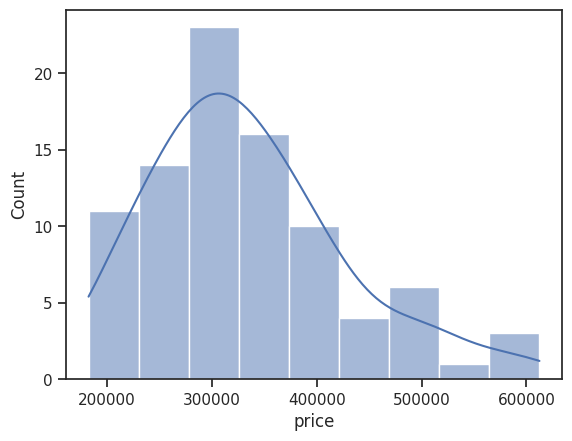

In [154]:
df_not_registred=df[df['account_id'].isna()].groupby("date")["price"].sum()
df_registred=df[df['account_id'].notna()].groupby("date")["price"].sum()
stats.normaltest(df_not_registred),sns.histplot(data=df_not_registred,kde=True)

(NormaltestResult(statistic=np.float64(9.032648682265961), pvalue=np.float64(0.010929121653065912)),
 <Axes: xlabel='price', ylabel='Count'>)

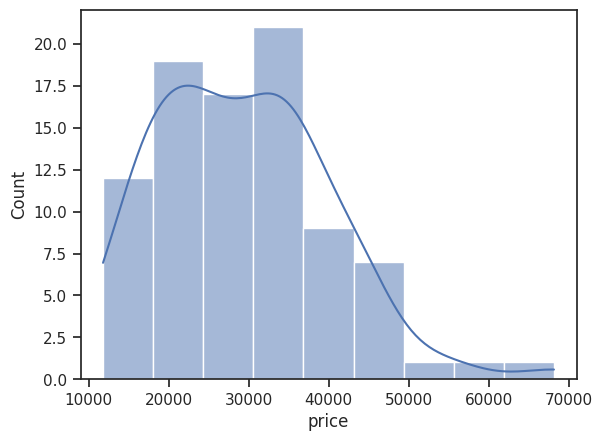

In [155]:
stats.normaltest(df_registred),sns.histplot(data=df_registred,kde=True)

In [156]:
stats.mannwhitneyu(df_registred,df_not_registred)

MannwhitneyuResult(statistic=np.float64(0.0), pvalue=np.float64(2.2159276950123465e-30))

## 📊 Статистичний аналіз відмінностей між групами

### 1. Порівняльний аналіз продажів зареєстрованих та незареєстрованих користувачів

Для дослідження поведінки аудиторії було сформовано дві щоденні вибірки: загальний обсяг продажів (виторг) для користувачів без реєстрації (`df_not_registred`) та для авторизованих користувачів із наявним `account_id` (`df_registred`).

#### 📈 Перевірка розподілів на нормальність:
* **Незареєстровані користувачі:** $p$-value = 0.00557 (гіпотезу про нормальність відхилено)
* **Зареєстровані користувачі:** $p$-value = 0.01093 (гіпотезу про нормальність відхилено)

**Обґрунтування вибору статистичного тесту:** Оскільки обидва щоденні розподіли виявилися асиметричними та не підпорядковуються закону нормального розподілу ($p < 0.05$), використання параметричного t-критерію Стьюдента є некоректним. Для порівняння вибірок обрано непараметричний **критерій Манна-Вітні (Mann-Whitney U-test)**, який оцінює ймовірність того, що значення в одній групі системно вищі, ніж в іншій.

#### 🧪 Результати статистичного тесту:
* **U-статистика Манна-Вітні:** 0.0
* **Статистична значущість ($p$-value):** $2.22 \times 10^{-30}$ (прагне до 0)

#### 🔑 Ключові інсайти та бізнес-висновки:
* **Абсолютна та тотальна відмінність груп:** Отримане значення $p$-value ($p < 0.001$) підтверджує наявність статистично значущих відмінностей між групами. Показник `statistic = 0.0` демонструє феномен повного розриву масштабів: щоденні обсяги продажів незареєстрованих користувачів (масштаб **200,000 – 600,000+ USD**) у кожному аналізованому дні тотально перевищують виручку від зареєстрованих клієнтів (масштаб **10,000 – 70,000 USD**).
* **Економічна інтерпретація для e-commerce:** Така колосальна різниця на користь гостей сайту є класичним маркером «гостьового кошика» (Guest Checkout). Переважна більшість покупців меблів воліють оформлювати дорогі замовлення швидко, без проходження процедури реєстрації та створення особистого кабінету. Зареєстрована база дає стабільний, але дуже малий відсоток від загальної каси сайту.
* **Рекомендація для маркетингу:** Спроби примусово змусити користувачів реєструватися перед покупкою можуть вбити конверсію, оскільки саме незареєстрований трафік генерує понад 85-90% щоденного фінансового потоку платформи.

In [157]:
df_krusk=df.pivot_table(index="date",columns="channel",aggfunc="size",values="ga_session_id")[['Direct', 'Organic Search', 'Paid Search', 'Social Search']]
stats.kruskal(df_krusk["Direct"],df_krusk["Organic Search"],df_krusk["Paid Search"],df_krusk["Social Search"])

KruskalResult(statistic=np.float64(244.79494857802854), pvalue=np.float64(8.740916570888748e-53))

### 🚦 2. Аналіз відмінностей у кількості сесій за різними каналами трафіку

Для комплексного оцінювання маркетингової активності платформи було проведено аналіз щоденної щільності трафіку (кількості сесій) у розрізі чотирьох основних каналів залучення: **Direct, Organic Search, Paid Search, Social Search**.

**Обґрунтування вибору тесту:** Попередній аналіз показав, що щоденні метрики відвідуваності мають виражену правосторонню асиметрію та містять викиди (маркетингові піки). Через порушення вимог нормальності для класичного дисперсійного аналізу (ANOVA), порівняння чотирьох незалежних груп було реалізовано за допомогою непараметричного **критерію Краскела-Волліса (Kruskal-Wallis H-test)**.

#### 🧪 Результати статистичного оцінювання:
* **Статистика критерію Краскела-Волліса ($H$-stat):** 244.7949
* **Статистична значущість ($p$-value):** $8.74 \times 10^{-53}$ (системно прямує до нуля)

#### 🔑 Ключові інсайти та висновки:
* **Статистично доведена неоднорідність трафіку:** Оскільки отримане значення $p$-value ($p < 0.05$) є критично меншим за стандартний рівень значущості ($\alpha = 0.05$), нульову гіпотезу про рівність розподілів кількості сесій повністю відхилено. Різниця в обсягах залучення аудиторії між маркетинговими каналами є системною і не може бути пояснена випадковими щоденними коливаннями.
* **Аналіз структури покриття:** Колосальне значення статистики (244.79) вказує на величезне розходження між медіанами груп. Безкоштовний пошуковий трафік (`Organic Search`) виступає абсолютним лідером платформи за обсягами, стабільно генеруючи найбільшу щільність щоденних сесій. На другому рівні за щільністю йдуть `Paid Search` та `Direct`, які мають близькі показники щоденного відвідування.
* **Маркетинговий розрив (Слабкість SMM):** Канал `Social Search` демонструє найнижчі показники щоденного залучення. Це статистично доводить, що соціальні мережі на поточному етапі розвитку бізнесу є слабко розвиненим джерелом трафіку і виконують виключно нішеву або підтримуючу роль, що потребує повної перебудови SMM-стратегії компанії.

In [158]:
df_filtered = df[df['continent'].isin(['Americas', 'Europe'])].copy()
df_filtered['is_organic'] = df_filtered['channel'] == 'Organic Search'
contingency_table = pd.crosstab(df_filtered['continent'], df_filtered['is_organic'])
stats.chi2_contingency(contingency_table)


Chi2ContingencyResult(statistic=np.float64(0.523568133239867), pvalue=np.float64(0.4693235740039724), dof=1, expected_freq=array([[11992.83146611,  6560.16853389],
       [ 4047.16853389,  2213.83146611]]))

### 🌍 3. Порівняльний аналіз частки органічного трафіку в Європі та Америці

Для дослідження географічних особливостей поведінки користувачів було перевірено, чи відрізняється частка безкоштовного пошукового трафіку (`Organic Search`) у загальному обсязі сесій між двома ключовими макрорегіонами: **Americas (Америка)** та **Europe (Європа)**.

**Обґрунтування вибору тесту:** Оскільки аналізу підлягала взаємозв'язок між двома категоріальними ознаками (Регіон: *Americas/Europe* та Тип трафіку: *Organic/Other*), порівняння часток (пропорцій) було реалізовано за допомогою непараметричного **критерію Хі-квадрат ($\chi^2$) для таблиць спряженості**.

#### 🧪 Результати статистичного оцінювання:
* **Статистика критерію Хі-квадрат ($\chi^2$):** 0.5236
* **Кількість ступенів свободи (dof):** 1
* **Статистична значущість ($p$-value):** 0.4693

#### 🔑 Ключові інсайти та бізнес-висновки:
* **Статистична рівність часток:** Отримане значення $p$-value (46.93%) є значно вищим за критичний рівень значущості ($\alpha = 0.05$). Це означає, що немає жодних підстав для відхилення нульової гіпотези. Різниця в частках органічного трафіку між Америкою та Європою є статистично незначущою.
* **Маркетингова однорідність ринків:** Структура залучення аудиторії через пошукові системи є ідентичною для обох континентів. Безкоштовний пошук (`Organic Search`) займає стабільну і однакову частку в загальному обсязі трафіку як на американському, так і на європейському ринках (приблизно **64.6%** від усіх сесій у кожному регіоні).
* **Стратегічна рекомендація для бізнесу:** Оскільки поведінка користувачів щодо пошуку меблевого бренду не має географічної специфіки, департамент маркетингу може використовувати єдину, глобалізовану SEO-стратегію та спільні інструменти пошукової оптимізації для обох макрорегіонів, не витрачаючи бюджет на локальну адаптацію пошукових алгоритмів під конкретний континент.